In [17]:
# Step 1: Import required libraries and modules
import sys, os
sys.path.append(os.path.abspath("..")) 

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

from models.mobilenetv3 import MobileNetV3Extractor
from models.lstm_attention import BiLSTMWithAttention
from preprocessing.dataset import SignLanguageDataset

In [18]:
import torch
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

CUDA available: False
Using device: cpu


In [19]:
# Step 2: Define data paths and label mapping

train_root = "../data/frames/train"
val_root = "../data/frames/validation"

# Obtain the category list and establish the tag mapping.
class_names = sorted([
    d for d in os.listdir(train_root)
    if os.path.isdir(os.path.join(train_root, d)) and not d.startswith(".")
])
label_map = {name: idx for idx, name in enumerate(class_names)}

print("Discovered classes:", label_map)
print("Total number of classes:", len(label_map))

Discovered classes: {'accident': 0, 'africa': 1, 'all': 2, 'apple': 3, 'basketball': 4, 'bed': 5, 'before': 6, 'bird': 7, 'birthday': 8, 'black': 9, 'blue': 10, 'book': 11, 'bowling': 12, 'brown': 13, 'but': 14, 'can': 15, 'candy': 16, 'chair': 17, 'change': 18, 'cheat': 19, 'city': 20, 'clothes': 21, 'color': 22, 'computer': 23, 'cook': 24, 'cool': 25, 'corn': 26, 'cousin': 27, 'cow': 28, 'dance': 29, 'dark': 30, 'deaf': 31, 'decide': 32, 'doctor': 33, 'dog': 34, 'drink': 35, 'eat': 36, 'enjoy': 37, 'family': 38, 'fine': 39, 'finish': 40, 'fish': 41, 'forget': 42, 'full': 43, 'give': 44, 'go': 45, 'graduate': 46, 'hat': 47, 'hearing': 48, 'help': 49, 'hot': 50, 'how': 51, 'jacket': 52, 'kiss': 53, 'language': 54, 'last': 55, 'later': 56, 'letter': 57, 'like': 58, 'man': 59, 'many': 60, 'medicine': 61, 'meet': 62, 'mother': 63, 'need': 64, 'no': 65, 'now': 66, 'orange': 67, 'paint': 68, 'paper': 69, 'pink': 70, 'pizza': 71, 'play': 72, 'pull': 73, 'purple': 74, 'right': 75, 'same': 76,

In [20]:
# Step 3: Define two different data augmentation strategies

# Basic transforms (for experiment 1)
train_transform_basic = A.Compose([
    A.Resize(128, 128),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Enhanced transforms (for experiment 2)
train_transform_aug = A.Compose([
    A.Resize(128, 128),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.RandomRotate90(p=0.3),
    A.CoarseDropout(max_holes=8, max_height=8, max_width=8, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Validation transforms (same for both experiments)
val_transform = A.Compose([
    A.Resize(128, 128),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

print("Data augmentation strategies defined:")
print("Basic transforms:", len(train_transform_basic))
print("Enhanced transforms:", len(train_transform_aug))

Data augmentation strategies defined:
Basic transforms: 3
Enhanced transforms: 7


/var/folders/w0/p53f__b5775fykd_h2t7wtqw0000gp/T/ipykernel_90305/929399228.py:16: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=8, max_width=8, p=0.3),


In [21]:
# Step 4: Define the full model structure

class FullSLRModel(nn.Module):
    def __init__(self, num_classes, hidden_dim=128, num_layers=2):
        super().__init__()
        self.feature_extractor = MobileNetV3Extractor()
        self.temporal_model = BiLSTMWithAttention(
            input_dim=960, 
            hidden_dim=hidden_dim, 
            num_classes=num_classes,
            num_layers=num_layers
        )

    def forward(self, x):  # x: [B, T, C, H, W]
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        features = self.feature_extractor(x)  # [B*T, 960]
        features = features.view(B, T, -1)    # [B, T, 960]
        logits, _ = self.temporal_model(features)
        return logits

In [22]:
# Step 5: Define training and validation functions

from torch.cuda.amp import autocast, GradScaler

def train_epoch(model, train_loader, criterion, optimizer, scaler, device):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0
    
    loop = tqdm(train_loader, desc='Training')
    for batch_idx, (videos, labels) in enumerate(loop):
        videos = videos.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        with autocast():
            outputs = model(videos)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        train_loss += loss.item()
        
        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)
    
    train_loss = train_loss / len(train_loader)
    train_acc = 100. * correct / total
    return train_loss, train_acc

def validate(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for videos, labels in tqdm(val_loader, desc='Validating'):
            videos = videos.to(device)
            labels = labels.to(device)
            
            with autocast():
                outputs = model(videos)
                loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss = val_loss / len(val_loader)
    val_acc = 100. * correct / total
    return val_loss, val_acc

In [ ]:
# Step 6: Experiment 1 - MobileNetV3 + LSTM + Attention (Basic)

print("EXPERIMENT 1: MobileNetV3 + LSTM + Attention (Basic)")

# Check if there is a saved model to enable continued training.
start_epoch = 0
if os.path.exists('experiment1_best_model.pth'):
    model_basic.load_state_dict(torch.load('experiment1_best_model.pth'))
    print("Loaded existing experiment1 model, continuing training...")
    start_epoch = 2 
else:
    print("Starting experiment1 training from scratch...")

# Create datasets and dataloaders for experiment 1
train_dataset_basic = SignLanguageDataset(
    root_dir=train_root,
    label_map=label_map,
    transform=train_transform_basic
)

val_dataset = SignLanguageDataset(
    root_dir=val_root,
    label_map=label_map,
    transform=val_transform
)

train_loader_basic = DataLoader(train_dataset_basic, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)

# Initialize model, criterion, optimizer for experiment 1
model_basic = FullSLRModel(num_classes=len(label_map)).to(device)
criterion_basic = nn.CrossEntropyLoss(label_smoothing=0)  # No label smoothing
optimizer_basic = optim.Adam(model_basic.parameters(), lr=1e-3, weight_decay=1e-4)
scaler_basic = GradScaler()

# Training loop for experiment 1
num_epochs = 22
train_loss_list_basic, val_loss_list_basic = [], []
train_acc_list_basic, val_acc_list_basic = [], []
best_val_acc_basic = 0.0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    # Training
    train_loss, train_acc = train_epoch(
        model_basic, train_loader_basic, criterion_basic, 
        optimizer_basic, scaler_basic, device
    )
    
    # Validation
    val_loss, val_acc = validate(model_basic, val_loader, criterion_basic, device)
    
    # Record metrics
    train_loss_list_basic.append(train_loss)
    train_acc_list_basic.append(train_acc)
    val_loss_list_basic.append(val_loss)
    val_acc_list_basic.append(val_acc)
    
    # Save best model
    if val_acc > best_val_acc_basic:
        best_val_acc_basic = val_acc
        torch.save(model_basic.state_dict(), 'experiment1_best_model.pth')
        print(f'New best model saved with val_acc: {val_acc:.2f}%')
    
    print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

print(f"\nExperiment 1 - Best Validation Accuracy: {best_val_acc_basic:.2f}%")

EXPERIMENT 1: MobileNetV3 + LSTM + Attention (Basic)
Loaded existing experiment1 model, continuing training...

[DEBUG] First 5 samples loaded:
Sample 0: class=apple, label=3
    Frame count: 16 | First frame: ../data/frames/train/apple/68003/frame_000.jpg
Sample 1: class=apple, label=3
    Frame count: 16 | First frame: ../data/frames/train/apple/65084/frame_000.jpg
Sample 2: class=apple, label=3
    Frame count: 16 | First frame: ../data/frames/train/apple/70309/frame_000.jpg
Sample 3: class=apple, label=3
    Frame count: 16 | First frame: ../data/frames/train/apple/03003/frame_000.jpg
Sample 4: class=apple, label=3
    Frame count: 16 | First frame: ../data/frames/train/apple/65085/frame_000.jpg

[DEBUG] First 5 samples loaded:
Sample 0: class=apple, label=3
    Frame count: 16 | First frame: ../data/frames/validation/apple/69213/frame_000.jpg
Sample 1: class=apple, label=3
    Frame count: 16 | First frame: ../data/frames/validation/apple/02999/frame_000.jpg
Sample 2: class=apple,

Validating: 100%|██████████| 61/61 [01:18<00:00,  1.29s/it]


New best model saved with val_acc: 0.83%
Epoch 1: Train Loss: 4.6447 | Train Acc: 0.70% | Val Loss: 4.6155 | Val Acc: 0.83%

Epoch 2/22


Training:  54%|█████▍    | 135/250 [08:49<07:17,  3.80s/it, acc=0.926, loss=4.66]

In [24]:
# Step 7: Experiment 2 - MobileNetV3 + LSTM + Attention + Augmentation + Label Smoothing

print("EXPERIMENT 2: MobileNetV3 + LSTM + Attention + Augmentation + Label Smoothing")

# Check if there is a saved model to enable continued training.
start_epoch = 0
if os.path.exists('experiment2_best_model.pth'):
    model_aug.load_state_dict(torch.load('experiment2_best_model.pth'))
    print("Loaded existing experiment2 model, continuing training...")
    start_epoch = 2 
else:
    print("Starting experiment2 training from scratch...")

# Create datasets and dataloaders for experiment 2
train_dataset_aug = SignLanguageDataset(
    root_dir=train_root,
    label_map=label_map,
    transform=train_transform_aug
)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=4, shuffle=True, num_workers=2)

# Initialize model, criterion, optimizer for experiment 2
model_aug = FullSLRModel(num_classes=len(label_map)).to(device)
criterion_aug = nn.CrossEntropyLoss(label_smoothing=0.1)  # With label smoothing
optimizer_aug = optim.Adam(model_aug.parameters(), lr=1e-3, weight_decay=1e-4)
scaler_aug = GradScaler()

# Training loop for experiment 2
train_loss_list_aug, val_loss_list_aug = [], []
train_acc_list_aug, val_acc_list_aug = [], []
best_val_acc_aug = 0.0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    # Training
    train_loss, train_acc = train_epoch(
        model_aug, train_loader_aug, criterion_aug, 
        optimizer_aug, scaler_aug, device
    )
    
    # Validation
    val_loss, val_acc = validate(model_aug, val_loader, criterion_aug, device)
    
    # Record metrics
    train_loss_list_aug.append(train_loss)
    train_acc_list_aug.append(train_acc)
    val_loss_list_aug.append(val_loss)
    val_acc_list_aug.append(val_acc)
    
    # Save best model
    if val_acc > best_val_acc_aug:
        best_val_acc_aug = val_acc
        torch.save(model_aug.state_dict(), 'experiment2_best_model.pth')
        print(f'New best model saved with val_acc: {val_acc:.2f}%')
    
    print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

print(f"\nExperiment 2 - Best Validation Accuracy: {best_val_acc_aug:.2f}%")


EXPERIMENT 2: MobileNetV3 + LSTM + Attention + Augmentation + Label Smoothing

[DEBUG] First 5 samples loaded:
Sample 0: class=apple, label=3
    Frame count: 16 | First frame: ../data/frames/train/apple/68003/frame_000.jpg
Sample 1: class=apple, label=3
    Frame count: 16 | First frame: ../data/frames/train/apple/65084/frame_000.jpg
Sample 2: class=apple, label=3
    Frame count: 16 | First frame: ../data/frames/train/apple/70309/frame_000.jpg
Sample 3: class=apple, label=3
    Frame count: 16 | First frame: ../data/frames/train/apple/03003/frame_000.jpg
Sample 4: class=apple, label=3
    Frame count: 16 | First frame: ../data/frames/train/apple/65085/frame_000.jpg

Epoch 1/2


Validating: 100%|██████████| 61/61 [01:54<00:00,  1.87s/it]


New best model saved with val_acc: 1.65%
Epoch 1: Train Loss: 4.6119 | Train Acc: 1.10% | Val Loss: 4.6070 | Val Acc: 1.65%

Epoch 2/2


Validating: 100%|██████████| 61/61 [01:52<00:00,  1.84s/it]

Epoch 2: Train Loss: 4.5897 | Train Acc: 2.40% | Val Loss: 4.5999 | Val Acc: 1.24%

Experiment 2 - Best Validation Accuracy: 1.65%


COMPARISON RESULTS
Experiment 1 (Basic): Best Val Acc = 1.24%
Experiment 2 (Augmented): Best Val Acc = 1.65%
Improvement: 0.41%


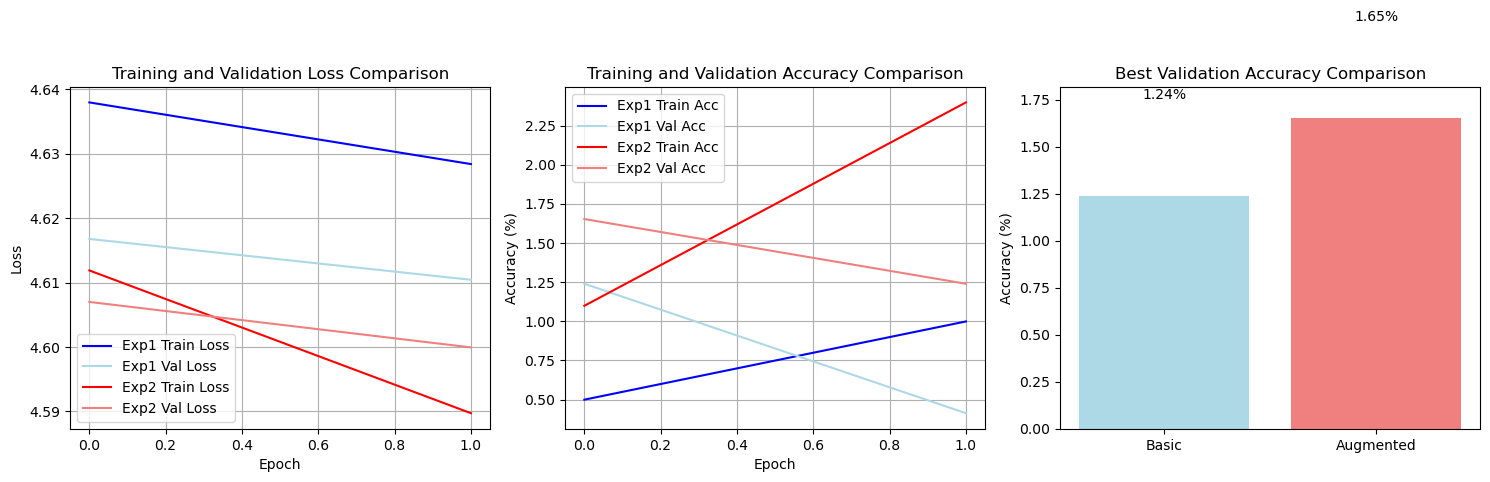


Detailed Comparison:
Metric               Experiment 1    Experiment 2    Difference     
-----------------------------------------------------------------
Best Val Acc         1.24            1.65            0.41           
Final Train Acc      1.00            2.40            1.40           
Final Val Acc        0.41            1.24            0.83           


In [27]:
# Step 8: Compare and visualize results

print("COMPARISON RESULTS")

print(f"Experiment 1 (Basic): Best Val Acc = {best_val_acc_basic:.2f}%")
print(f"Experiment 2 (Augmented): Best Val Acc = {best_val_acc_aug:.2f}%")
print(f"Improvement: {best_val_acc_aug - best_val_acc_basic:.2f}%")

# Create comparison plots
plt.figure(figsize=(15, 5))

# Loss comparison
plt.subplot(1, 3, 1)
plt.plot(train_loss_list_basic, label='Exp1 Train Loss', color='blue')
plt.plot(val_loss_list_basic, label='Exp1 Val Loss', color='lightblue')
plt.plot(train_loss_list_aug, label='Exp2 Train Loss', color='red')
plt.plot(val_loss_list_aug, label='Exp2 Val Loss', color='lightcoral')
plt.title('Training and Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy comparison
plt.subplot(1, 3, 2)
plt.plot(train_acc_list_basic, label='Exp1 Train Acc', color='blue')
plt.plot(val_acc_list_basic, label='Exp1 Val Acc', color='lightblue')
plt.plot(train_acc_list_aug, label='Exp2 Train Acc', color='red')
plt.plot(val_acc_list_aug, label='Exp2 Val Acc', color='lightcoral')
plt.title('Training and Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Final comparison bar chart
plt.subplot(1, 3, 3)
experiments = ['Basic', 'Augmented']
best_accs = [best_val_acc_basic, best_val_acc_aug]
colors = ['lightblue', 'lightcoral']
bars = plt.bar(experiments, best_accs, color=colors)
plt.title('Best Validation Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, max(best_accs) * 1.1)

# Add value labels on bars
for bar, acc in zip(bars, best_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{acc:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print detailed comparison
print("\nDetailed Comparison:")
print(f"{'Metric':<20} {'Experiment 1':<15} {'Experiment 2':<15} {'Difference':<15}")
print("-" * 65)
print(f"{'Best Val Acc':<20} {best_val_acc_basic:<15.2f} {best_val_acc_aug:<15.2f} {best_val_acc_aug - best_val_acc_basic:<15.2f}")
print(f"{'Final Train Acc':<20} {train_acc_list_basic[-1]:<15.2f} {train_acc_list_aug[-1]:<15.2f} {train_acc_list_aug[-1] - train_acc_list_basic[-1]:<15.2f}")
print(f"{'Final Val Acc':<20} {val_acc_list_basic[-1]:<15.2f} {val_acc_list_aug[-1]:<15.2f} {val_acc_list_aug[-1] - val_acc_list_basic[-1]:<15.2f}")

In [28]:
# Step 9: Save experiment results

import json
from datetime import datetime

# Create results dictionary
results = {
    'experiment_info': {
        'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'num_classes': len(label_map),
        'num_epochs': num_epochs,
        'device': str(device)
    },
    'experiment_1': {
        'name': 'MobileNetV3 + LSTM + Attention (Basic)',
        'data_augmentation': 'Basic (Resize + Normalize)',
        'label_smoothing': 0,
        'best_val_acc': best_val_acc_basic,
        'train_loss_history': train_loss_list_basic,
        'val_loss_history': val_loss_list_basic,
        'train_acc_history': train_acc_list_basic,
        'val_acc_history': val_acc_list_basic
    },
    'experiment_2': {
        'name': 'MobileNetV3 + LSTM + Attention + Augmentation + Label Smoothing',
        'data_augmentation': 'Enhanced (Flip + Brightness + Rotation + Dropout)',
        'label_smoothing': 0.1,
        'best_val_acc': best_val_acc_aug,
        'train_loss_history': train_loss_list_aug,
        'val_loss_history': val_loss_list_aug,
        'train_acc_history': train_acc_list_aug,
        'val_acc_history': val_acc_list_aug
    }
}

# Save results to JSON file
with open('contrast_experiment_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\nExperiment results saved to 'contrast_experiment_results.json'")
print("Best models saved as:")
print("- experiment1_best_model.pth")
print("- experiment2_best_model.pth")


Experiment results saved to 'contrast_experiment_results.json'
Best models saved as:
- experiment1_best_model.pth
- experiment2_best_model.pth
